In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
historico = pd.read_csv("world_olympedia_olympics_game_medal_tally.csv")
historico.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146


In [24]:
# Ler e processar os dados das olimpiadas de verão de paris de 2024
paris = pd.read_csv("medals_total.csv")
paris = paris.rename(columns={
    "country_code":"country_noc",
    "Gold Medal":"gold",
    "Silver Medal" : "silver",
    "Bronze Medal" : "bronze",
    "Total": "total"
})
paris["year"] = 2024
paris["edition"] = "2024 Summer Olympics"
paris["edition_id"] = 999 # id ficticio


paris.head()

,country_noc,country,country_long,gold,silver,bronze,total,year,edition,edition_id
0,USA,United States,United States of America,40,44,42,126,2024,2024 Summer Olympics,999
1,CHN,China,People's Republic of China,40,27,24,91,2024,2024 Summer Olympics,999
2,JPN,Japan,Japan,20,12,13,45,2024,2024 Summer Olympics,999
3,AUS,Australia,Australia,18,19,16,53,2024,2024 Summer Olympics,999
4,FRA,France,France,16,26,22,64,2024,2024 Summer Olympics,999


In [26]:
# Concatenar paris com o histórico
olimpiadas = pd.concat([historico, paris])
olimpiadas.tail()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total,season,country_long
87,2024,2024 Summer Olympics,999,Peru,PER,0,0,1,1,NaN,Peru
88,2024,2024 Summer Olympics,999,Qatar,QAT,0,0,1,1,NaN,Qatar
89,2024,2024 Summer Olympics,999,Singapore,SGP,0,0,1,1,NaN,Singapore
90,2024,2024 Summer Olympics,999,Slovakia,SVK,0,0,1,1,NaN,Slovakia
91,2024,2024 Summer Olympics,999,Zambia,ZAM,0,0,1,1,NaN,Zambia


In [27]:
# Criar uma coluna de "temporada" para classificar entre Verão e inverno
olimpiadas["season"] = olimpiadas["edition"].str.extract(r'(Summer|Winter)')
olimpiadas.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total,season,country_long
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47,Summer,NaN
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112,Summer,NaN
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48,Summer,NaN
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248,Summer,NaN
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146,Summer,NaN


In [46]:
verao = olimpiadas[olimpiadas["season"] == "Summer"]
inverno = olimpiadas[olimpiadas["season"] == "Winter"]

In [47]:
pd.set_option('display.max_rows', None)

In [57]:
# medalhas de olimpiadas de verão
medalhas_verao = verao.groupby("country")[["gold", "silver", "bronze", "total"]].sum().sort_values(by=["total"], ascending=False)

print(medalhas_verao)

                                       gold  silver  bronze  total
country                                                           
United States                          1110     885     786   2781
Soviet Union                            395     319     296   1010
Great Britain                           305     345     342    992
France                                  247     283     307    837
Germany                                 249     277     298    824
Italy                                   234     206     229    669
People's Republic of China              263     199     174    636
Australia                               180     189     225    594
Japan                                   189     162     193    544
Hungary                                 188     163     183    534
Sweden                                  150     181     184    515
Russian Federation                      148     130     153    431
East Germany                            153     129     127   

In [58]:
# medalhas de olimpiadas de inverno
medalhas_inverno = inverno.groupby("country")[["gold", "silver", "bronze", "total"]].sum().sort_values(by=["total"], ascending=False)

print(medalhas_inverno)

                                       gold  silver  bronze  total
country                                                           
Norway                                  148     134     123    405
United States                           113     122      95    330
Germany                                 112     104      70    286
Austria                                  71      88      91    250
Canada                                   77      72      76    225
Soviet Union                             78      57      59    194
Sweden                                   65      51      60    176
Finland                                  45      65      65    175
Switzerland                              63      47      58    168
Netherlands                              53      49      45    147
Italy                                    42      43      56    141
France                                   41      42      55    138
Russian Federation                       46      39      35   

In [56]:
# medalhas totais
medalhas_totais = olimpiadas.groupby("country")[["gold", "silver", "bronze", "total"]].sum().sort_values(by=["total"], ascending=False)

print(medalhas_totais)

                                       gold  silver  bronze  total
country                                                           
United States                          1235    1013     887   3135
Soviet Union                            473     376     355   1204
Germany                                 367     390     374   1131
Great Britain                           326     361     366   1053
France                                  303     334     378   1015
Italy                                   283     257     289    829
People's Republic of China              285     231     197    713
Sweden                                  220     237     251    708
Japan                                   206     190     224    620
Australia                               186     196     234    616
Canada                                  157     191     232    580
Norway                                  212     189     176    577
Hungary                                 192     170     192   

In [51]:
# pegar os top 50
top50_inverno = medalhas_inverno.sort_values(by=["total"], ascending=False).head(50)
top50_verao = medalhas_veraoo.sort_values(by=["total"], ascending=False).head(50)
top50 = medalhas_totais.sort_values(by=["total"], ascending=False).head(50)

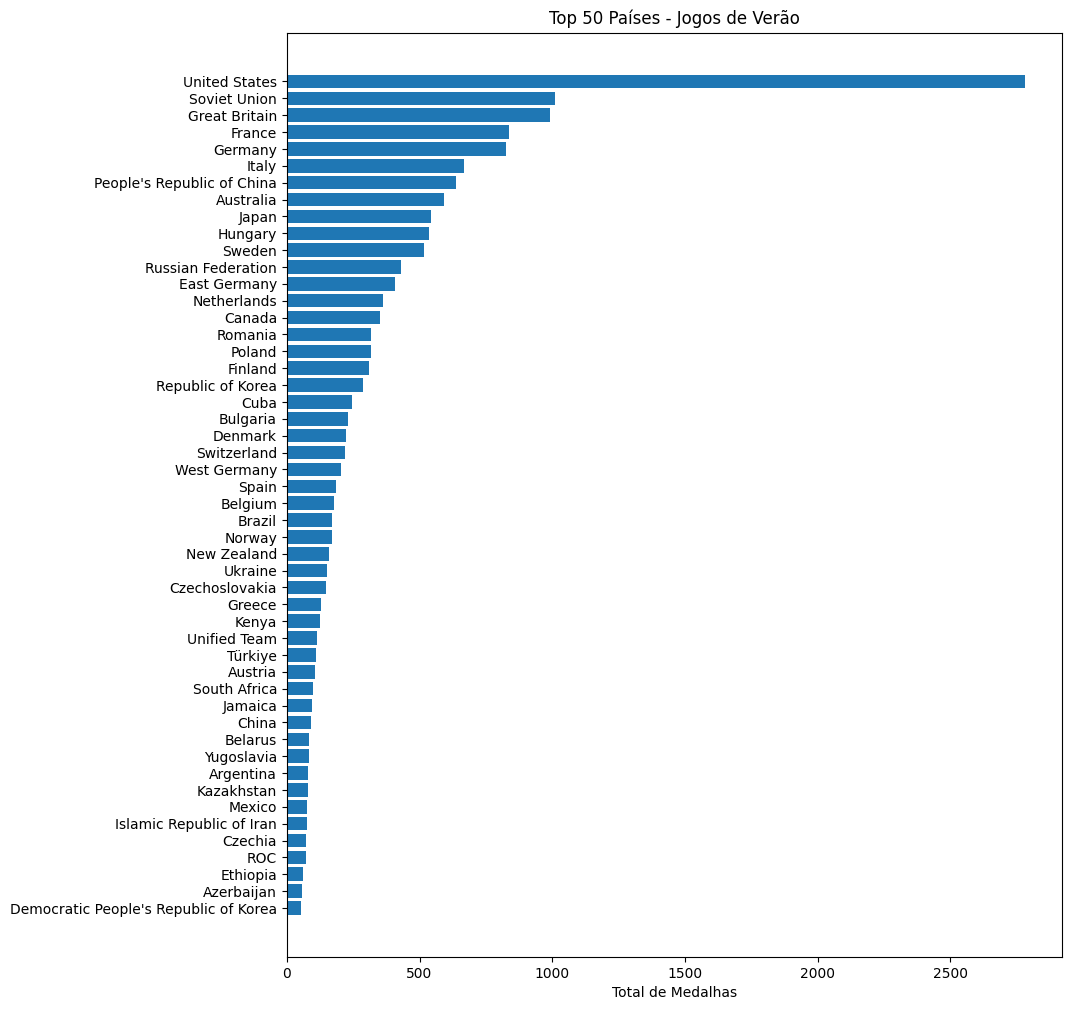

In [52]:
# Verão
plt.figure(figsize=(10,12))
plt.barh(top50_verao.index, top50_verao["total"])
plt.title("Top 50 Países - Jogos de Verão")
plt.xlabel("Total de Medalhas")
plt.gca().invert_yaxis()
plt.show()

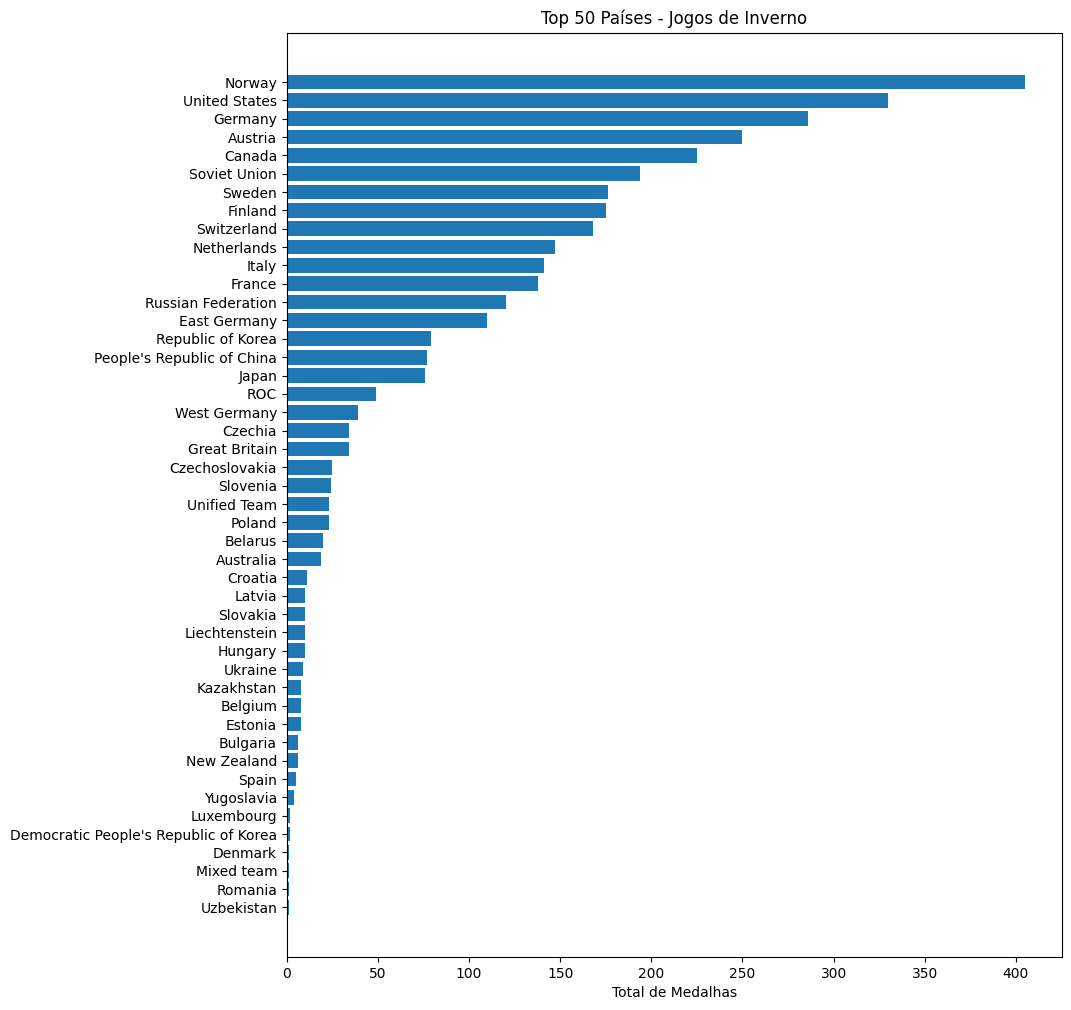

In [53]:
# Inverno
plt.figure(figsize=(10,12))
plt.barh(top50_inverno.index, top50_inverno["total"])
plt.title("Top 50 Países - Jogos de Inverno")
plt.xlabel("Total de Medalhas")
plt.gca().invert_yaxis()
plt.show()

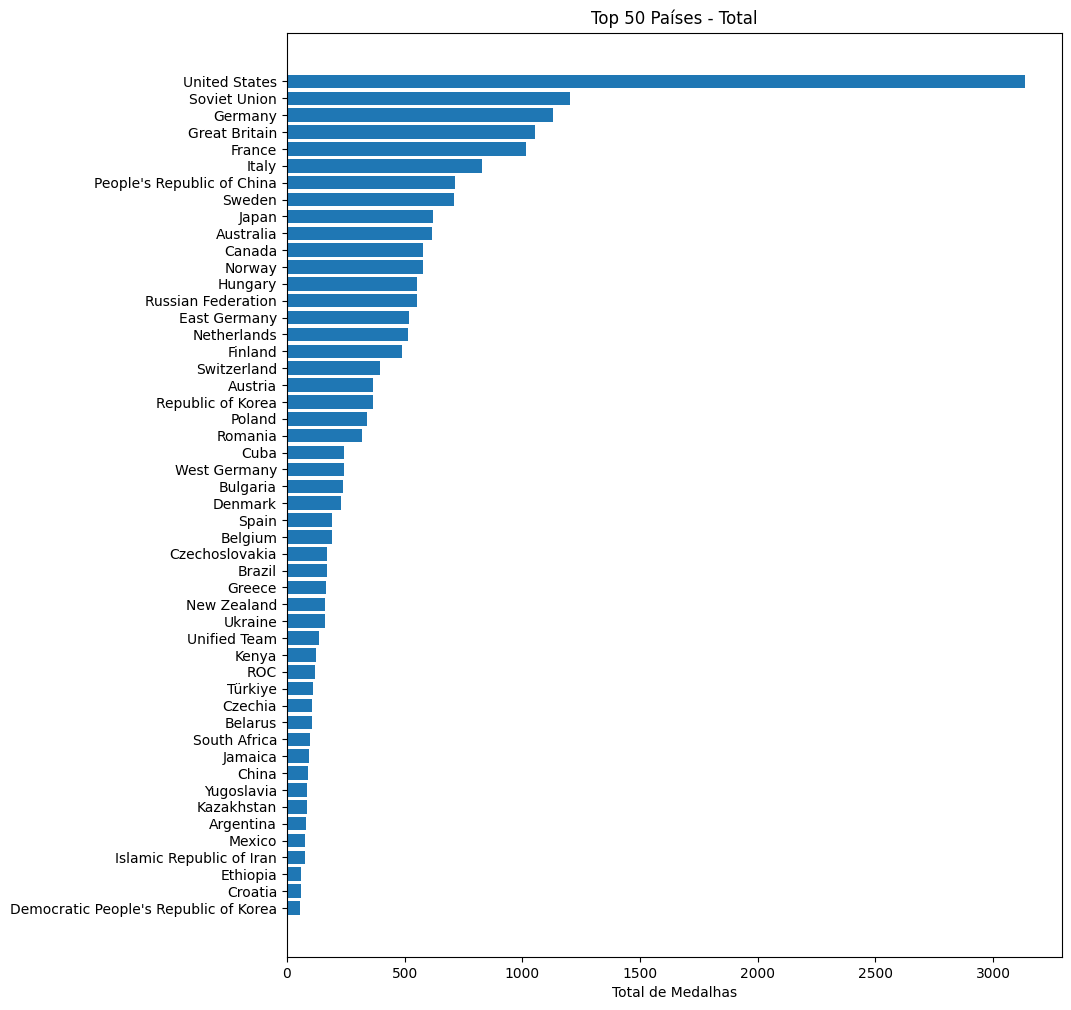

In [54]:
# Total
plt.figure(figsize=(10,12))
plt.barh(top50.index, top50["total"])
plt.title("Top 50 Países - Total")
plt.xlabel("Total de Medalhas")
plt.gca().invert_yaxis()
plt.show()